In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


In [146]:
# hydroview_grid_subsample.py
import numpy as np
import xarray as xr
# from scipy import ndimage
# import warnings

class HydroViewerSubsampler:
    """
    Poseidon-style grid subsampling for HydroViewer xarray data
    Adapted from Poseidon's grid_subsample.py
    """
    
    def __init__(self, data, resolution=256):
        """
        Parameters
        ----------
        data : xr.DataArray
            Your data with dims (time, category, lat, lon)
        resolution : int
            Tile resolution (pixels per tile)
        """
        self.full_data = data
        self.resolution = resolution
        self.lat = data.lat.values
        self.lon = data.lon.values
        self.nlat = len(self.lat)
        self.nlon = len(self.lon)
        
        # Calculate grid spacing
        self.dlat = np.abs(np.diff(self.lat).mean())
        self.dlon = np.abs(np.diff(self.lon).mean())
        
        print(f"Full grid: {self.nlat}×{self.nlon} = {self.nlat*self.nlon:,} cells")
        print(f"Grid spacing: Δlat={self.dlat:.4f}°, Δlon={self.dlon:.4f}°")
    
    def find_common_factors(self, num1, num2):
        """Find all common factors of two numbers (from Poseidon)"""
        common = []
        g = np.gcd(num1, num2)
        for i in range(1, int(np.sqrt(g)) + 1):
            if g % i == 0:
                common.append(i)
                if g != i * i:
                    common.append(g // i)
        return np.array(sorted(common))
    
    def pick_grain_sizes(self, zooms, factor=1.0):
        """
        Calculate appropriate grain size for each zoom level
        Adapted from Poseidon's pick_grain_size
        
        Parameters
        ----------
        zooms : list or np.ndarray
            Zoom levels (e.g., [0, 1, 2, 3, 4, 5])
        factor : float
            Adjustment factor for grain selection
        
        Returns
        -------
        grains : list
            Grain size for each zoom level
        """
        # Representative grid spacing in meters (approximate)
        rep_dx = 111000 * self.dlon  # degrees to meters at equator
        
        # Calculate required resolution at each zoom level
        # Web Mercator: world width = 2^zoom * tile_resolution pixels
        interp_dx = 6371e3 * 2 * np.pi / (2**np.array(zooms)) / self.resolution
        
        # Find available grain sizes (factors of grid dimensions)
        avail = self.find_common_factors(self.nlat, self.nlon)
        avail_dx = avail * rep_dx
        
        print(f"\nAvailable grain sizes: {avail}")
        print(f"Available resolutions (m): {avail_dx}")
        
        grains = []
        for zoom, dx in zip(zooms, interp_dx):
            # Find grain that gives resolution closest to target
            idx = np.searchsorted(avail_dx, dx * factor)
            idx = min(idx, len(avail) - 1)
            grain = avail[idx]
            grains.append(grain)
            
            actual_res = avail_dx[idx]
            print(f"Zoom {zoom}: target={dx:.0f}m, actual={actual_res:.0f}m, grain={grain}")
        
        return grains
    
    def subsample_data(self, grain):
        """
        Subsample data by taking every grain-th point
        Adapted from Poseidon's subsample_ocedata
        
        Parameters
        ----------
        grain : int
            Subsampling factor
        
        Returns
        -------
        subsampled : xr.DataArray
            Coarse-grained data
        """
        if grain == 1:
            return self.full_data
        
        # Calculate starting indices (centered sampling)
        lat_start = int(np.ceil(grain / 2) - 1)
        lon_start = int(np.ceil(grain / 2) - 1)
        
        # Subsample using slice
        subsampled = self.full_data.isel(
            lat=slice(lat_start, self.nlat, grain),
            lon=slice(lon_start, self.nlon, grain)
        )
        
        print(f"  Grain {grain}: {len(subsampled.lat)}×{len(subsampled.lon)} = "
              f"{len(subsampled.lat)*len(subsampled.lon):,} cells "
              f"({100*(1-len(subsampled.lat)*len(subsampled.lon)/(self.nlat*self.nlon)):.1f}% reduction)")
        
        return subsampled
    
    def generate_pyramid(self, zooms=None):
        """
        Generate the full resolution pyramid
        
        Parameters
        ----------
        zooms : list, optional
            Zoom levels to generate. Default: [0, 1, 2, 3, 4, 5]
        
        Returns
        -------
        pyramid : dict
            Dictionary mapping zoom level to data
        grain_map : dict
            Dictionary mapping zoom level to grain size
        """
        if zooms is None:
            zooms = list(range(6))  # 6 levels like your sketch
        
        print("\n" + "="*60)
        print("GENERATING RESOLUTION PYRAMID")
        print("="*60)
        
        # Calculate grain sizes
        grains = self.pick_grain_sizes(zooms)
        
        # Get unique grains
        unique_grains = sorted(set(grains))
        
        print(f"\nUnique grain sizes needed: {unique_grains}")
        print("\nSubsampling data...")
        
        # Create subsampled datasets
        grain_to_data = {}
        for grain in unique_grains:
            grain_to_data[grain] = self.subsample_data(grain)
        
        # Map zoom levels to data
        pyramid = {}
        grain_map = {}
        for zoom, grain in zip(zooms, grains):
            pyramid[zoom] = grain_to_data[grain]
            grain_map[zoom] = grain
        
        print("\n" + "="*60)
        print("PYRAMID SUMMARY")
        print("="*60)
        for zoom in zooms:
            data = pyramid[zoom]
            grain = grain_map[zoom]
            print(f"Zoom {zoom}: {len(data.lat):4d}×{len(data.lon):4d} cells, grain={grain:2d}")
        
        return pyramid, grain_map


def lonlat_for_tile(zoom, tile_x, tile_y, resolution=256):
    """
    Create lat/lon coordinates for a Web Mercator tile
    Adapted from Poseidon's lonlat4global_map
    
    Parameters
    ----------
    zoom : int
        Zoom level
    tile_x : int
        Tile X coordinate
    tile_y : int
        Tile Y coordinate
    resolution : int
        Pixels per tile
    
    Returns
    -------
    lon, lat : np.ndarray
        2D arrays of coordinates
    """
    n_tiles = 2 ** zoom
    data_bounds = {'lon_min': -81.975, 'lon_max': -49.025, 'lat_min': -20.975, 'lat_max': 5.975}
    # Total extent
    lon_min, lon_max = data_bounds['lon_min'], data_bounds['lon_max']
    lat_min, lat_max = data_bounds['lat_min'], data_bounds['lat_max']

    # Size of each tile in degrees
    tile_width_lon = (lon_max - lon_min) / n_tiles
    tile_height_lat = (lat_max - lat_min) / n_tiles

    # Tile bounds
    tile_lon_min = lon_min + tile_x * tile_width_lon
    tile_lon_max = lon_min + (tile_x + 1) * tile_width_lon
    tile_lat_min = lat_min + tile_y * tile_height_lat
    tile_lat_max = lat_min + (tile_y + 1) * tile_height_lat

    # Create pixel coordinates within this tile
    lon_1d = np.linspace(tile_lon_min, tile_lon_max, resolution)
    lat_1d = np.linspace(tile_lat_min, tile_lat_max, resolution)
    
    lon, lat = np.meshgrid(lon_1d, lat_1d)
    
    return lon, lat
    

def get_tile_data(pyramid, zoom, tile_x, tile_y, time_idx=0, category_idx=0):
    """
    Extract data for a specific tile at a given zoom level
    
    Parameters
    ----------
    pyramid : dict
        Resolution pyramid from generate_pyramid
    zoom : int
        Zoom level
    tile_x, tile_y : int
        Tile coordinates
    time_idx : int
        Time index
    category_idx : int
        Category index
    
    Returns
    -------
    tile_data : np.ndarray
        256×256 array of data values
    lon, lat : np.ndarray
        Coordinate grids
    """
    # Get coordinates for this tile
    lon, lat = lonlat_for_tile(zoom, tile_x, tile_y)
    print(f"Tile bounds: lon=[{lon.min():.2f}, {lon.max():.2f}], "
        f"lat=[{lat.min():.2f}, {lat.max():.2f}]")
    
    # Get appropriate resolution data
    data = pyramid[zoom]
    # Select time and category
    data_slice = data.isel(time=time_idx, category=category_idx)

    # Get valid (non-NaN) points only
    # valid_mask = ~np.isnan(data)
    
    # if valid_mask.sum() == 0:
    #     print("WARNING: All data is NaN!")
    #     return np.full(lon.shape, np.nan), lon, lat
    
    # valid_points = np.column_stack([
    #     data_slice[valid_mask],
    #     data_slice[valid_mask]
    # ])
    # valid_values = data_slice[valid_mask]

    # from scipy.interpolate import NearestNDInterpolator

    # #Create interpolator using only valid points
    # interp = NearestNDInterpolator(valid_points, valid_values)

    # # Interpolate
    # lat_flat = lat.ravel()
    # lon_flat = lon.ravel()
    # points = np.column_stack([lat_flat, lon_flat])
    
    # tile_data_flat = interp(points)
    # tile_data = tile_data_flat.reshape(lon.shape)

    # Interpolate to tile coordinates
    # This is where you'd implement more sophisticated interpolation
    # For now, using simple nearest neighbor
    tile_data_flat = data_slice.interp(
        lat=xr.DataArray(lat.ravel(), dims='points'),
        lon=xr.DataArray(lon.ravel(), dims='points'),
        method='nearest'
    ).values
    print(f'\n Type {type(tile_data_flat)}')
    tile_data = tile_data_flat.reshape(lon.shape)
    
    return tile_data, lon, lat

In [147]:
ds = xr.open_dataset('../get_ldas_probabilistic_output/prob_2024_12_31_tercile_probability_max_Evap_tavg_lvl_0.nc')
ds = ds['Evap_tavg']
ds

<xarray.DataArray 'Evap_tavg' (category: 3, time: 6, lat: 540, lon: 660)> Size: 51MB
[6415200 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 48B 2024-12-31 2025-01-31 ... 2025-05-31
  * lat       (lat) float64 4kB -20.98 -20.93 -20.88 ... 5.875 5.925 5.975
  * lon       (lon) float64 5kB -81.97 -81.92 -81.88 ... -49.13 -49.08 -49.03
  * category  (category) int32 12B 0 1 2

In [148]:
# Create subsampler
subsampler = HydroViewerSubsampler(ds, resolution=256)

# Generate 6-level pyramid (like your sketch)
pyramid, grain_map = subsampler.generate_pyramid(zooms=[0, 1, 2, 3, 4, 5])

# Example: Get tile for zoom=3, tile coordinates (2, 1)
tile_data, lon, lat = get_tile_data(
    pyramid, 
    zoom=2, 
    tile_x=2, 
    tile_y=1,
    time_idx=0,
    category_idx=0
)

# Visualize
# plt.figure(figsize=(10, 8))
# plt.pcolormesh(lon, lat, tile_data, cmap='viridis')
# plt.colorbar(label='Value')
# plt.title('Tile at Zoom=3, X=2, Y=1')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.show()

Full grid: 540×660 = 356,400 cells
Grid spacing: Δlat=0.0500°, Δlon=0.0500°

GENERATING RESOLUTION PYRAMID

Available grain sizes: [ 1  2  3  4  5  6 10 12 15 20 30 60]
Available resolutions (m): [  5550.          11100.          16650.          22200.
  27750.          33300.          55500.          66600.
  83250.         110999.99999999 166499.99999999 332999.99999998]
Zoom 0: target=156368m, actual=166500m, grain=30
Zoom 1: target=78184m, actual=83250m, grain=15
Zoom 2: target=39092m, actual=55500m, grain=10
Zoom 3: target=19546m, actual=22200m, grain=4
Zoom 4: target=9773m, actual=11100m, grain=2
Zoom 5: target=4886m, actual=5550m, grain=1

Unique grain sizes needed: [1, 2, 4, 10, 15, 30]

Subsampling data...
  Grain 2: 270×330 = 89,100 cells (75.0% reduction)
  Grain 4: 135×165 = 22,275 cells (93.8% reduction)
  Grain 10: 54×66 = 3,564 cells (99.0% reduction)
  Grain 15: 36×44 = 1,584 cells (99.6% reduction)
  Grain 30: 18×22 = 396 cells (99.9% reduction)

PYRAMID SUMMARY
Zoom 0

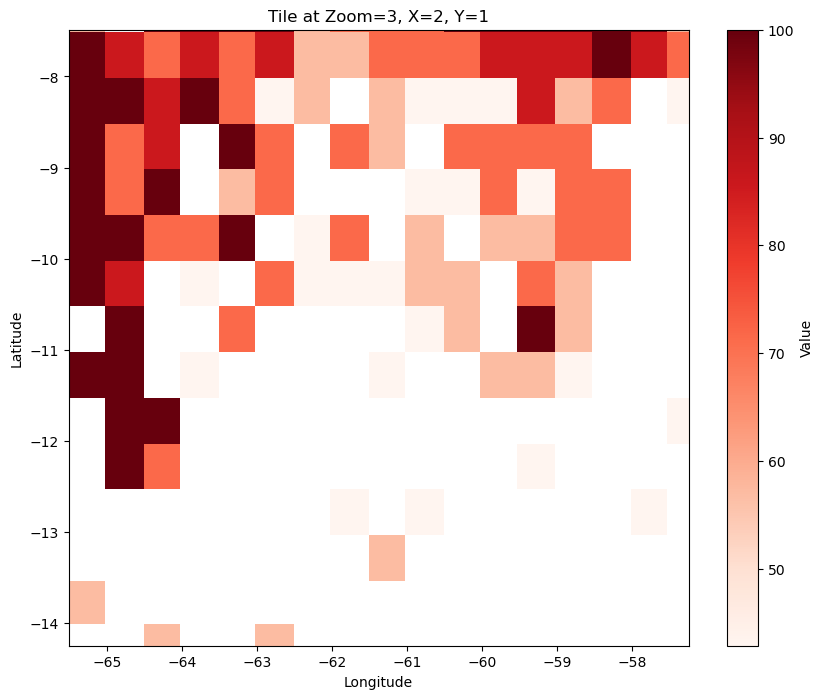

In [149]:
# Visualize
plt.figure(figsize=(10, 8))
plt.pcolormesh(lon, lat, tile_data, cmap='Reds')
plt.colorbar(label='Value')
plt.title('Tile at Zoom=3, X=2, Y=1')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Tile bounds: lon=[-81.97, -80.95], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-80.95, -79.92], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-79.92, -78.89], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-78.89, -77.86], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-77.86, -76.83], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-76.83, -75.80], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-75.80, -74.77], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-74.77, -73.74], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-73.74, -72.71], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-72.71, -71.68], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-71.68, -70.65], lat=[-20.98, -20.13]

 Type <class 'numpy.ndarray'>
Tile bounds: lon=[-70.65, -69.62], lat=[-20

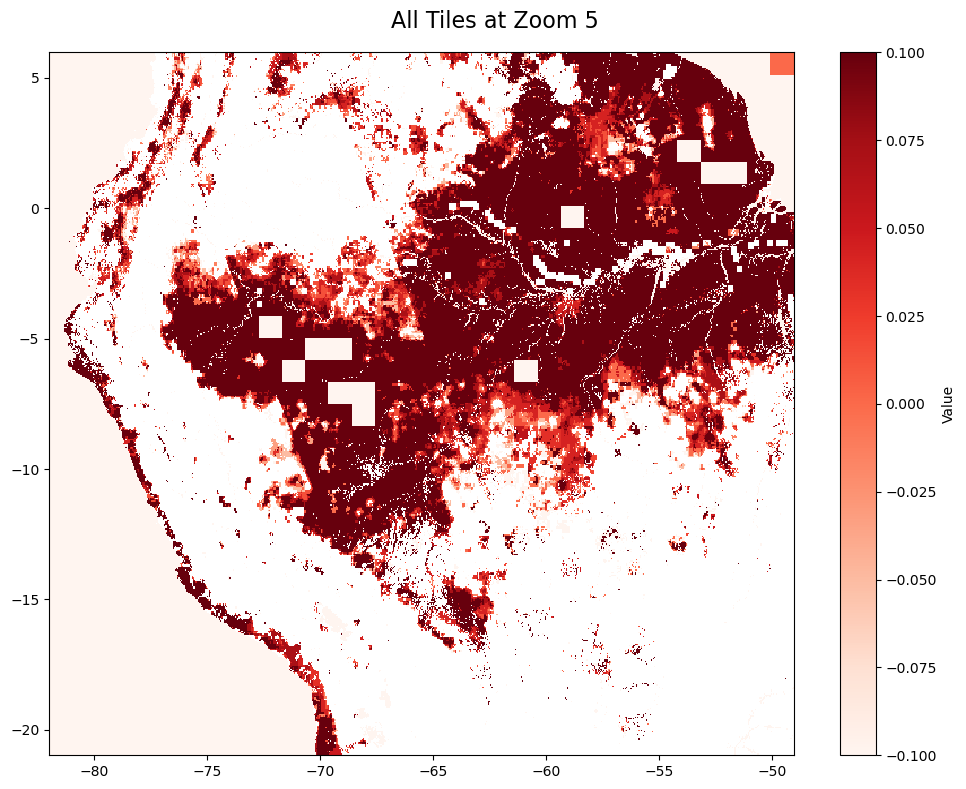

In [150]:
def visualize_all_tiles(pyramid, zoom, data_bounds = {'lon_min': -81.975, 'lon_max': -49.025, 'lat_min': -20.975, 'lat_max': 5.975}
, time_idx=0, category_idx=0):
    """Show all tiles at a given zoom level"""
    n_tiles = 2 ** zoom
    
    plt.figure(figsize=(10, 8))
    
    # if n_tiles == 1:
    #     axes = np.array([[axes]])
    # elif n_tiles == 2:
    #     axes = axes.reshape(2, 2)
    
    for tile_y in range(n_tiles):
        for tile_x in range(n_tiles):
            #ax = axes[tile_y, tile_x]
            
            tile_data, lon, lat = get_tile_data(
                pyramid, zoom, tile_x, tile_y,
                time_idx, category_idx
            )
            
            plt.pcolormesh(lon, lat, tile_data, cmap='Reds', shading='auto')
            # ax.set_title(f'Tile ({tile_x}, {tile_y})')
            # ax.set_xlabel('Longitude')
            # ax.set_ylabel('Latitude')
            # plt.colorbar(im, ax=ax)
    
    plt.suptitle(f'All Tiles at Zoom {zoom}', fontsize=16)
    plt.colorbar(label='Value')
    plt.tight_layout()
    plt.show()

# Use it
visualize_all_tiles(pyramid, zoom=5)